In [20]:
!pip install legacy-cgi opendatasets --quiet
import opendatasets as od

od.download("https://www.kaggle.com/datasets/marquis03/bean-leaf-lesions-classification")

Skipping, found downloaded files in "./bean-leaf-lesions-classification" (use force=True to force download)


In [21]:
import torch
import torch.nn
from torch.optim import Adam
from torchvision.transforms import transforms
from torch.utils.data import DataLoader , Dataset
from torchvision import models
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from PIL import Image
import os

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print (device)
print(os.listdir("/content"))

cuda
['.config', 'bean-leaf-lesions-classification', 'sample_data']


In [22]:
train_df = pd.read_csv("/content/bean-leaf-lesions-classification/train.csv")
val_df = pd.read_csv("/content/bean-leaf-lesions-classification/val.csv")

train_df["image:FILE"] = "/content/bean-leaf-lesions-classification/" + train_df["image:FILE"]
val_df["image:FILE"] = "/content/bean-leaf-lesions-classification/" + val_df["image:FILE"]

train_df.head()

,image:FILE,category
0,/content/bean-leaf-lesions-classification/trai...,0
1,/content/bean-leaf-lesions-classification/trai...,0
2,/content/bean-leaf-lesions-classification/trai...,0
3,/content/bean-leaf-lesions-classification/trai...,0
4,/content/bean-leaf-lesions-classification/trai...,0


In [23]:
# now we will check how many unique classes we have for our training data
print(train_df['category'].unique())

print(train_df.shape)
print(val_df.shape)

[0 1 2]
(1034, 2)
(133, 2)


In [24]:
print(train_df['category'].value_counts())

category
2    348
1    345
0    341
Name: count, dtype: int64


In [25]:
Transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor(),
    transforms.ConvertImageDtype(torch.float)
])

In [26]:
class CustomImageDataset(Dataset):
  def __init__(self,dataframe,transform=None):
    self.dataframe = dataframe
    self.transform = transform
    self.labels = torch.tensor(dataframe['category']).to(device)

  def __len__(self):
    return self.dataframe.shape[0]

  def __getitem__(self,index):
    image_path = self.dataframe.iloc[index,0]
    label = self.labels[index]
    image = Image.open(image_path)
    if self.transform:
      image = (self.transform(image)/255.0).to(device)
    return image , label




In [27]:
train_dataset = CustomImageDataset(train_df,transform= Transform)
val_dataset = CustomImageDataset(val_df ,transform = Transform)

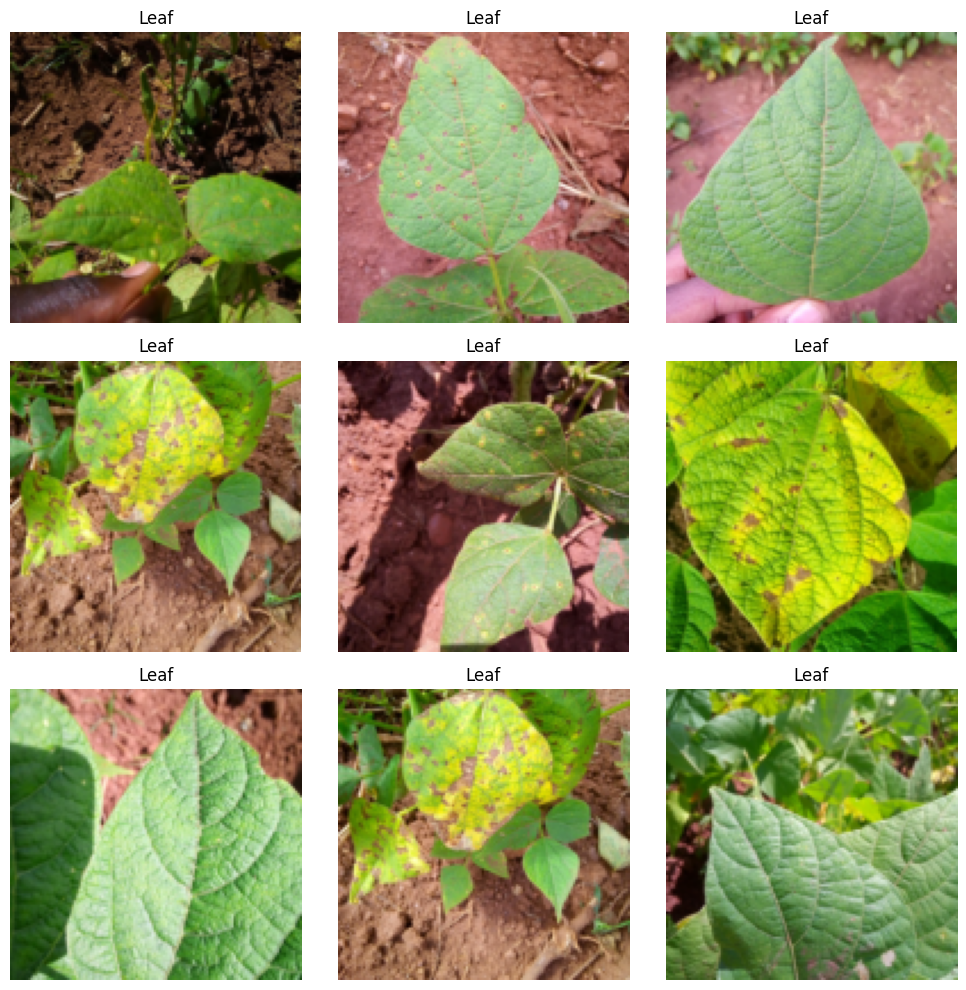

In [28]:
nrows = 3
ncols = 3

fig , axs = plt.subplots(nrows,ncols,figsize=(10,10))

for i in range (nrows):
  for j in range (ncols):
    image = train_dataset[np.random.randint(0,train_dataset.__len__())][0].cpu()
    axs[i,j].imshow((image*255.0).squeeze().permute(1,2,0))
    axs[i,j].set_title("Leaf")
    axs[i,j].axis("off")

plt.tight_layout()
plt.show()


In [29]:
#defining constants
LR = 1e-3
BATCH_SIZE = 4
EPOCH = 15

In [30]:
train_dataloader = DataLoader(train_dataset,batch_size = BATCH_SIZE, shuffle = True )
val_dataloader = DataLoader(val_dataset,batch_size = BATCH_SIZE, shuffle = True )


In [31]:
# Heres the extra part you have to perform for using pretrained model
# There are two methods to do this one is transfer learning and second is train from scratch

In [32]:
# now move the model to device
googlenet_model = models.googlenet(weights='DEFAULT')

for i in googlenet_model.parameters():
  i.requires_grad = True

In [33]:
googlenet_model.fc

Linear(in_features=1024, out_features=1000, bias=True)

In [34]:
# now you have to change the out_features to you classes numbers so first find the unique classes count
length = len(train_df['category'].unique())

googlenet_model.fc = torch.nn.Linear(googlenet_model.fc.in_features,length)
# now after converting move it to device
googlenet_model.to(device)

GoogLeNet(
  (conv1): BasicConv2d(
    (conv): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
  (conv2): BasicConv2d(
    (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (conv3): BasicConv2d(
    (conv): Conv2d(64, 192, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(192, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
  (inception3a): Inception(
    (branch1): BasicConv2d(
      (conv): Conv2d(192, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track

In [35]:
# loss and acc function var
losscal = torch.nn.CrossEntropyLoss()
acc = Adam(googlenet_model.parameters(),lr=LR)

# four arrays for ploting
total_train_loss = []
total_val_loss = []
total_train_acc = []
total_val_acc = []

for epoch in range(EPOCH):
  train_loss =0
  train_acc=0
  val_loss =0
  val_acc=0
  for data in train_dataloader:
    image,label = data
    acc.zero_grad()
    output = googlenet_model(image)
    loss  = losscal(output,label)
    train_loss+= loss.item()
    loss.backward()
    accu = (torch.argmax(output, axis= 1 ) == label).sum().item()
    train_acc+=accu
    acc.step()
  with torch.no_grad():
      for data in val_dataloader:
        image,label = data
        output = googlenet_model(image)
        loss  = losscal(output,label)
        val_loss+= loss.item()
        accu = (torch.argmax(output, axis= 1 ) == label).sum().item()
        val_acc+=accu
  total_train_loss.append(round(train_loss/1000,4))
  total_train_acc.append(round(train_acc/train_dataset.__len__() ,4))
  total_val_loss.append(round(val_loss/1000,4))
  total_val_acc.append(round(val_acc/val_dataset.__len__() ,4))

  print(f"Train loss {round(train_loss/1000,4)} Train acc {round(train_acc/train_dataset.__len__() ,4)} Val loss {round(val_loss/1000,4)} Val acc {round(val_acc/val_dataset.__len__() ,4)}")


Train loss 0.2451 Train acc 0.5677 Val loss 0.0257 Val acc 0.6466
Train loss 0.2152 Train acc 0.6383 Val loss 0.0284 Val acc 0.609
Train loss 0.2168 Train acc 0.6364 Val loss 0.0313 Val acc 0.6015
Train loss 0.177 Train acc 0.6992 Val loss 0.0235 Val acc 0.6917
Train loss 0.1658 Train acc 0.7389 Val loss 0.0253 Val acc 0.7368
Train loss 0.1814 Train acc 0.705 Val loss 0.0254 Val acc 0.6316
Train loss 0.1495 Train acc 0.766 Val loss 0.0208 Val acc 0.7444
Train loss 0.1387 Train acc 0.7872 Val loss 0.0179 Val acc 0.8195
Train loss 0.1289 Train acc 0.8124 Val loss 0.0143 Val acc 0.8421
Train loss 0.1305 Train acc 0.8046 Val loss 0.0126 Val acc 0.8872
Train loss 0.1141 Train acc 0.8346 Val loss 0.0161 Val acc 0.8647
Train loss 0.1201 Train acc 0.8385 Val loss 0.0158 Val acc 0.8045
Train loss 0.1106 Train acc 0.8133 Val loss 0.0151 Val acc 0.8195
Train loss 0.0935 Train acc 0.8578 Val loss 0.0149 Val acc 0.8571
Train loss 0.0922 Train acc 0.8598 Val loss 0.0145 Val acc 0.8647


In [36]:
with torch.no_grad():
  test_loss = 0
  test_acc = 0
  for data in val_dataloader:
    input , label = data
    output = googlenet_model(input)

    loss = losscal(output,label)
    test_loss += loss.item()
    acc = (torch.argmax(output ,axis=1)== label).sum().item()
    test_acc += acc
  print(f"Test loss {round(test_loss/1000,4)} Test acc {round(test_acc/val_dataset.__len__() ,4)}")


Test loss 0.0151 Test acc 0.8496


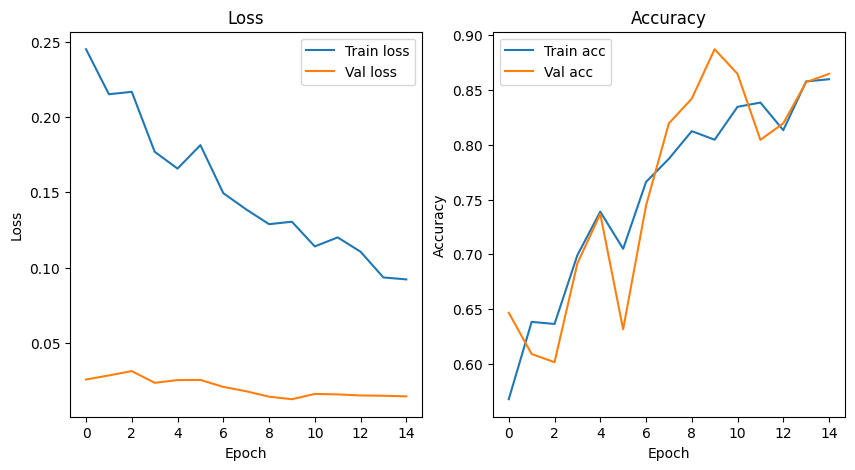

In [38]:
f , axs = plt.subplots(1,2,figsize=(10,5))

axs[0].plot(total_train_loss,label="Train loss")
axs[0].plot(total_val_loss,label="Val loss")
axs[0].set_title("Loss")
axs[0].set_xlabel("Epoch")
axs[0].set_ylabel("Loss")
axs[0].legend()

axs[1].plot(total_train_acc,label="Train acc")
axs[1].plot(total_val_acc,label="Val acc")
axs[1].set_title("Accuracy")
axs[1].set_xlabel("Epoch")
axs[1].set_ylabel("Accuracy")
axs[1].legend()

plt.show()